In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("expectation_decider_dataset.csv")
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,14,60,Yes,56,Fail
1,9,64,No,60,Fail
2,5,74,No,43,Fail
3,6,64,No,88,Fail
4,14,66,Yes,52,Fail


## 1. Understanding the Basics

## What is Probability?

Probability is the measure of how likely an event is to happen.

The value of probability lies between 0 and 1.

Probability = Number of favourable outcomes / Total number of outcomes

## Key Probability Terminology

1. Experiment:
   An activity that produces an outcome.

2. Sample Space:
   The collection of all possible outcomes.

3. Event:
   A specific outcome or group of outcomes.

4. Favourable Outcome:
   The outcome that satisfies the required condition.

5. Probability:
   The chance of occurrence of an event.

## Probability Events from the Dataset

### 1. Probability that a randomly selected student passes the final exam.

In [4]:
total_students = len(df)

pass_students = len(df[df["final_exam_pass"] == "Pass"])

pass_probability = pass_students / total_students

print("Probability of passing:", pass_probability)

Probability of passing: 0.71


### 2. Probability that a randomly selected student has attendance above 80%.

In [5]:
high_attendance = len(df[df["attendance"] > 80])

high_attendance_probability = high_attendance / total_students

print("Probability of attendance > 80% :", high_attendance_probability)

Probability of attendance > 80% : 0.465


### 3. Probability that a randomly selected student participates in group discussion.

In [6]:
group_yes = len(df[df["group_discussion"] == "Yes"])

group_probability = group_yes / total_students

print("Probability of participating in group discussion:", group_probability)

Probability of participating in group discussion: 0.515


## 2. Types of Events

### Empirical Probability

Empirical probability is calculated using actual observed data.

For example, probability that a randomly selected student passes the final exam:

Empirical Probability = Number of students who passed / Total number of students


In [7]:
pass_students = len(df[df["final_exam_pass"] == "Pass"])
total_students = len(df)

empirical_probability = pass_students / total_students

print("Empirical Probability of passing:", empirical_probability)

Empirical Probability of passing: 0.71


### Theoretical Probability

Theoretical probability is based on possible outcomes.

For example, if a fair coin is tossed, the probability of getting Heads is:

P(Heads) = 1 / 2 = 0.5

In [8]:
favorable_outcomes = 1

total_outcomes = 2

theoretical_probability = (
    favorable_outcomes / total_outcomes
)

print("Theoretical Probability of Pass:",
      theoretical_probability)

Theoretical Probability of Pass: 0.5


## 3. Random Variable and Probability Distribution

Let X be the number of students who pass the final exam out of 3 randomly selected students.

Therefore, X can have the following values:

X = 0, 1, 2, 3

Where:

X = 0 means no student passes.

X = 1 means one student passes.

X = 2 means two students pass.

X = 3 means all three students pass.

In [9]:
p = df["final_exam_pass"].value_counts(normalize=True)["Pass"]
print("Probability of Pass:", p)

q = 1 - p
print("Probability of Fail:", q)

Probability of Pass: 0.71
Probability of Fail: 0.29000000000000004


In [10]:
x = np.array([0, 1, 2, 3])

probabilities = np.array([
    q**3,
    3*p*(q**2),
    3*(p**2)*q,
    p**3
])

distribution = pd.DataFrame({
    "X": x,
    "P(X)": probabilities
})

distribution

,X,P(X)
0,0,0.024389
1,1,0.179133
2,2,0.438567
3,3,0.357911


In [11]:
# Mean = Σ [x × P(x)]
mean = np.sum(x * probabilities)
print("Mean:", mean)

Mean: 2.13


In [12]:
# Variance = Σ [x² × P(x)] − Mean²
variance = np.sum((x ** 2) * probabilities) - mean ** 2
print("Variance:", variance)

Variance: 0.6177000000000001


## 4. Venn Diagram in Probability

Event A = Students who study more than 10 hours per week.

Event B = Students who attend more than 80% of classes.

The overlapping area represents students who satisfy both conditions.

In [13]:
A = set(df[df["study_hours"] > 10].index)
B = set(df[df["attendance"] > 80].index)

print("Students studying more than 10 hours:", len(A))
print("Students with attendance more than 80%:", len(B))
print("Students satisfying both conditions:", len(A & B))

Students studying more than 10 hours: 95
Students with attendance more than 80%: 93
Students satisfying both conditions: 36


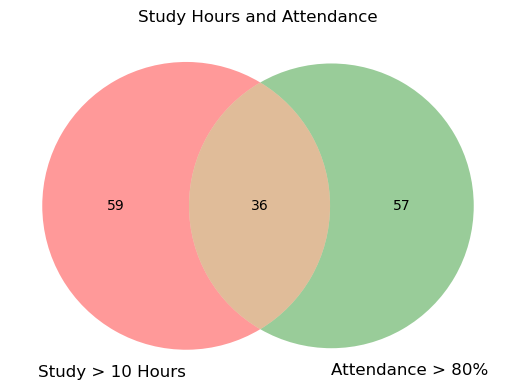

In [14]:
from matplotlib_venn import venn2

venn2([A, B], set_labels=("Study > 10 Hours", "Attendance > 80%"))

plt.title("Study Hours and Attendance")
plt.show()

## 5. Contingency Table and Probability Calculations

A contingency table shows the relationship between group discussion participation and final exam result.

In [21]:
table = pd.crosstab(
    df["group_discussion"],
    df["final_exam_pass"],margins=True)
table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,39,58,97
Yes,19,84,103
All,58,142,200


## Joint Probability

Group Discussion = Yes AND Pass

In [29]:
joint_probability = len(
    df[
        (df["group_discussion"] == "Yes") &
        (df["final_exam_pass"] == "Pass")
    ]
) / len(df)

print("Joint Probability:", joint_probability*100,"%")

Joint Probability: 42.0 %


## Marginal Probability

Pass

In [30]:
marginal_probability = len(
    df[df["final_exam_pass"] == "Pass"]
) / len(df)

print("Marginal Probability of Pass:", marginal_probability*100,"%")

Marginal Probability of Pass: 71.0 %


## Conditional Probability

Pass given Group Discussion = Yes

In [31]:
# Formula:
# P(Pass | Group Discussion) = P(Pass AND Group Discussion) / P(Group Discussion)

yes_students = len(df[df["group_discussion"] == "Yes"])

yes_and_pass = len(
    df[
        (df["group_discussion"] == "Yes") &
        (df["final_exam_pass"] == "Pass")])

conditional_probability = yes_and_pass / yes_students

print("Probability of passing given group discussion:",conditional_probability*100,"%")

Probability of passing given group discussion: 81.55339805825243 %


## 6. Understanding Relationships

### Conditional Probability Interpretation

Conditional probability tells us the probability of one event happening when we already know that another event has happened.

In this project, P(Pass | Group Discussion = Yes) tells us the probability that a student passes the exam among students who participated in group discussions.

### Independent or Dependent?

Two events are independent when the occurrence of one event does not affect the probability of the other event.

We compare:

P(Pass | Group Discussion = Yes)

with

P(Pass)

If the values are different, it suggests that the two events are dependent.

### Mutually Exclusive?

The events are not mutually exclusive because a student can participate in group discussion and also pass the exam.

In [32]:
pass_probability = len(
    df[df["final_exam_pass"] == "Pass"]
) / len(df)

print("P(Pass):", pass_probability*100,"%")
print("P(Pass | Group Discussion = Yes):", conditional_probability*100,"%")

P(Pass): 71.0 %
P(Pass | Group Discussion = Yes): 81.55339805825243 %


## 7. Bayes Theorem

Given:

P(High Attendance | Pass) = 0.70

P(High Attendance | Fail) = 0.40

P(High Attendance) = 0.60

We need to find:

P(Pass | High Attendance)

In [35]:
P_high_given_pass = 0.70
P_high_given_fail = 0.40
P_high = 0.60

P_pass = (P_high - P_high_given_fail) / (P_high_given_pass - P_high_given_fail)

P_fail = 1 - P_pass

P_pass_given_high = (P_high_given_pass * P_pass) / P_high

print("P(Pass):", P_pass)
print("P(Fail):", P_fail)
print("P(Pass | High Attendance):", P_pass_given_high)

P(Pass): 0.6666666666666666
P(Fail): 0.33333333333333337
P(Pass | High Attendance): 0.7777777777777777


## Final Summary

The analysis shows how probability can be used to understand student performance.

Study hours, attendance, group discussion participation, and previous test score are included as factors in the dataset.

The contingency table helps us compare group discussion participation with final exam results.

Conditional probability helps us understand the probability of passing when a student participates in group discussions.

Bayes Theorem shows how prior probability and attendance information can be combined to calculate the probability of passing given high attendance.

Overall, the project demonstrates the use of probability, random variables, probability distributions, contingency tables, conditional probability, Venn diagrams, and Bayes Theorem in an educational dataset.